In [22]:

# 将csv转换为h5ad数据
import pandas as pd
import numpy as np
import anndata as ad
from scipy import sparse

csv_file = "adata/roi_norm_ubc1e6.csv"

df = pd.read_csv(csv_file)

# 基因列：除了 x,y 以外的所有列
gene_cols = [c for c in df.columns if c not in ("x", "y")]

# obs：ROI 信息
obs = df[["x", "y"]].copy()
obs["roi_id"] = [f"{int(x)}_{int(y)}" for x, y in zip(obs["x"], obs["y"])]
obs = obs.set_index("roi_id")

# X：表达矩阵（nROI x nGene）
X = df[gene_cols].to_numpy(dtype=np.float32)

# 可选：转稀疏（如果大多数是 0，会省很多空间）
X = sparse.csr_matrix(X)

# var：基因信息
var = pd.DataFrame(index=pd.Index(gene_cols, name="gene"))

adata = ad.AnnData(X=X, obs=obs, var=var)
adata.write_h5ad("adata/roi_norm_ubc1e6.h5ad")

print(adata)


AnnData object with n_obs × n_vars = 245 × 1535
    obs: 'x', 'y'


count    1.500000e+01
mean     2.625620e+06
std      1.126912e+06
min      1.682749e+06
25%      2.036610e+06
50%      2.378067e+06
75%      2.509280e+06
max      5.964830e+06
Name: total_cpm, dtype: float64


c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\scanpy\preprocessing\_scale.py:186: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)
c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27840\3348670686.py:35: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.5, key_added="leiden_r06")


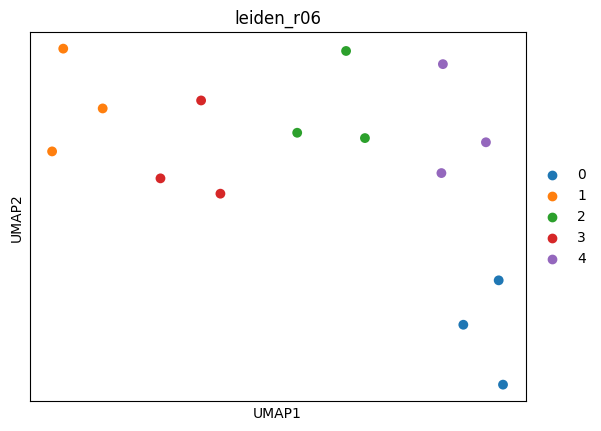

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

adata = sc.read_h5ad("adata/roi_norm_ubc1e6.h5ad")
adata = adata[adata.obs["x"] < 4].copy()
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 1), "sample"] = "spleem"
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 2), "sample"] = "liver"
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 3), "sample"] = "heart"
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 4), "sample"] = "kidney"
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 5), "sample"] = "lung"

# 如果你 X 是稀疏矩阵，sum 会返回矩阵，需要转一下
totals = np.asarray(adata.X.sum(axis=1)).ravel()
adata.obs["total_cpm"] = totals
adata.obs["n_genes_nonzero"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()

# 看看是否每个 ROI 总和≈1e6（允许少量数值误差；原本全0的 ROI 会是0）
print(adata.obs["total_cpm"].describe())
sc.pp.filter_cells(adata, min_genes=10)  # 你也可改成 50/100 视数据情况
# 或者按总量过滤
adata = adata[adata.obs["total_cpm"] > 0].copy()

#sc.pp.highly_variable_genes(adata, n_top_genes=1000, flavor="seurat_v3", subset=True)

adata.layers["cpm"] = adata.X.copy()   # 留一份原始 CPM
sc.pp.log1p(adata)                     # adata.X = log(1+CPM)
adata.layers["log1p_cpm"] = adata.X.copy()
sc.pp.scale(adata, max_value=100)        # 基于 log1p 后的值
sc.pp.filter_genes(adata, min_cells=1)   # 至少在1个ROI里非零

sc.tl.pca(adata, n_comps=10, svd_solver="arpack")

sc.pp.neighbors(adata, n_neighbors=5, n_pcs=10)
sc.tl.leiden(adata, resolution=1.5, key_added="leiden_r06")
sc.tl.umap(adata)

sc.pl.umap(adata, color=["leiden_r06"],size = 200)



In [31]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

cm = 1/2.54
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

outdir = Path("adata")
outdir.mkdir(exist_ok=True)

def discrete_palette(n):
    cmap = plt.get_cmap("tab20") if n <= 20 else plt.get_cmap("gist_ncar")
    return [cmap(i/(max(n-1, 1))) for i in range(n)]

def plot_umap_cat2(
    adata,
    key: str,
    stem: str,
    fig_cm=(6.0, 3.0),                 # 整张图的物理尺寸（可调）
    ax_pos=(0.00, 0.00, 0.60, 1.00),   # [left, bottom, width, height] (0-1) 可调
    s=50,
    legend=True,
    legend_anchor=(1.02, 1.0),         # 图例锚点（相对 ax 坐标系）
    legend_loc="upper left",
    keep_square_box=True,              # True: 强制框正方形；False: 允许长方形
    equal_data_units=False             # True: 数据单位等比例；False: 只保证框形状
):
    if "X_umap" not in adata.obsm:
        raise ValueError("adata.obsm['X_umap'] not found. Run sc.tl.umap(adata) first.")

    xy = adata.obsm["X_umap"]
    x, y = xy[:, 0], xy[:, 1]

    cat = adata.obs[key].astype("category")
    cats = list(cat.cat.categories)
    colors = discrete_palette(len(cats))
    cmap = dict(zip(cats, colors))

    fig = plt.figure(figsize=(fig_cm[0]*cm, fig_cm[1]*cm), dpi=300)
    ax = fig.add_axes(ax_pos)

    for c in cats:
        m = (cat.values == c)
        ax.scatter(x[m], y[m], s=s, c=[cmap[c]], label=str(c), linewidths=0)

    # 框、刻度
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_linewidth(0.6)

    # 关键：你可以选择“框正方形”还是“数据单位等比例”
    if keep_square_box:
        # 让框保持正方形（不会扁），不强制数据单位等比例
        ax.set_box_aspect(1)   # mpl>=3.3 有此函数
    if equal_data_units:
        # 数据单位等比例（可能导致点云看起来被压扁，但几何更真实）
        ax.set_aspect("equal", adjustable="datalim")

    if legend:
        ax.legend(
            loc=legend_loc,
            bbox_to_anchor=legend_anchor,
            frameon=False,
            borderaxespad=0.0,
            handletextpad=0.2,
            labelspacing=0.2,
            markerscale=0.8,
            prop={"family": "Arial", "size": 7},
        )

    fig.savefig(outdir / f"{stem}.pdf", dpi=300)
    fig.savefig(outdir / f"{stem}.svg", dpi=300)
    plt.close(fig)

# 示例：左边放 3cm×3cm 的正方形轴，右侧留 legend 空间
# 例如整图 6cm×3cm，ax 占宽 0.55，高 1.0（框正方形由 set_box_aspect 保证）
plot_umap_cat2(
    adata, "leiden_r06", "umap_leiden_r06",
    fig_cm=(6.0, 3.0),
    ax_pos=(0.00, 0.00, 0.55, 1.00),
    keep_square_box=True,
    equal_data_units=False,     # 若你想几何严格，改 True
    legend=True,
    legend_anchor=(1.02, 1.0)
)

plot_umap_cat2(
    adata, "sample", "umap_sample",
    fig_cm=(6.0, 3.0),
    ax_pos=(0.00, 0.00, 0.55, 1.00),
    keep_square_box=True,
    equal_data_units=False,
    legend=True,
    legend_anchor=(1.02, 1.0)
)


In [4]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# Style
# -----------------------
cm = 1/2.54
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

outdir = Path("adata")
outdir.mkdir(exist_ok=True)

# -----------------------
# Palette
# -----------------------
def discrete_palette(n):
    cmap = plt.get_cmap("tab20") if n <= 20 else plt.get_cmap("gist_ncar")
    if n <= 1:
        return [cmap(0)]
    return [cmap(i/(n-1)) for i in range(n)]

# -----------------------
# Plot: categorical UMAP
# -----------------------
def plot_umap_cat(
    adata, key, stem,
    fig_cm=(6.0, 3.0),
    ax_pos=(0.00, 0.00, 0.55, 1.00),
    s=50,
    legend=True,
    legend_anchor=(1.02, 1.0),
    legend_loc="upper left",
    keep_square_box=True,
    equal_data_units=False,
):
    if "X_umap" not in adata.obsm:
        raise ValueError("adata.obsm['X_umap'] not found. Run sc.tl.umap(adata) first.")

    xy = adata.obsm["X_umap"]
    x, y = xy[:, 0], xy[:, 1]

    cat = adata.obs[key].astype("category")
    cats = list(cat.cat.categories.astype(str))
    colors = discrete_palette(len(cats))
    cmap = dict(zip(cats, colors))

    fig = plt.figure(figsize=(fig_cm[0]*cm, fig_cm[1]*cm), dpi=300)
    ax = fig.add_axes(ax_pos)

    for c in cats:
        m = (cat.astype(str).values == c)
        ax.scatter(x[m], y[m], s=s, c=[cmap[c]], label=c, linewidths=0)

    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_linewidth(0.6)

    if keep_square_box:
        ax.set_box_aspect(1)
    if equal_data_units:
        ax.set_aspect("equal", adjustable="datalim")

    if legend:
        ax.legend(
            loc=legend_loc,
            bbox_to_anchor=legend_anchor,
            frameon=False,
            borderaxespad=0.0,
            handletextpad=0.2,
            labelspacing=0.2,
            markerscale=0.8,
            prop={"family": "Arial", "size": 7},
        )

    fig.savefig(outdir / f"{stem}.pdf", dpi=300, bbox_inches=None, pad_inches=0)
    plt.close(fig)

# -----------------------
# Plot: continuous UMAP
# -----------------------
def plot_umap_cont(
    adata, key, stem,
    fig_cm=(6.0, 3.0),
    ax_pos=(0.00, 0.00, 0.55, 1.00),
    cbar_pos=(0.58, 0.10, 0.03, 0.80),  # [l,b,w,h] in figure fraction
    s=50,
    cmap_name="viridis",
    vmin=None, vmax=None,
    keep_square_box=True,
    equal_data_units=False,
    log1p_color=False,                 # True: 用 log1p 压缩色阶
):
    if "X_umap" not in adata.obsm:
        raise ValueError("adata.obsm['X_umap'] not found. Run sc.tl.umap(adata) first.")
    if key not in adata.obs.columns:
        raise ValueError(f"{key} not in adata.obs")

    xy = adata.obsm["X_umap"]
    x, y = xy[:, 0], xy[:, 1]

    val = np.asarray(adata.obs[key]).astype(float)
    mask = np.isfinite(val)
    x2, y2, v2 = x[mask], y[mask], val[mask]

    if log1p_color:
        vplot = np.log1p(v2)
        cbar_label = f"log1p({key})"
    else:
        vplot = v2
        cbar_label = key

    fig = plt.figure(figsize=(fig_cm[0]*cm, fig_cm[1]*cm), dpi=300)
    ax = fig.add_axes(ax_pos)
    cax = fig.add_axes(cbar_pos)

    sca = ax.scatter(
        x2, y2, s=s, c=vplot, cmap=cmap_name,
        vmin=vmin, vmax=vmax, linewidths=0
    )

    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_linewidth(0.6)

    if keep_square_box:
        ax.set_box_aspect(1)
    if equal_data_units:
        ax.set_aspect("equal", adjustable="datalim")

    cb = plt.colorbar(sca, cax=cax)
    cb.set_label(cbar_label, labelpad=2)
    cb.ax.tick_params(labelsize=7, length=2)
    for sp in cb.ax.spines.values():
        sp.set_linewidth(0.6)

    fig.savefig(outdir / f"{stem}.pdf", dpi=300, bbox_inches=None, pad_inches=0)
    plt.close(fig)

# =========================
# 你要的 4 张图
# =========================
# 1) sample
plot_umap_cat(
    adata, "sample", "umap_sample",
    fig_cm=(6.0, 3.0),
    ax_pos=(0.00, 0.00, 0.55, 1.00),
    keep_square_box=True,
    equal_data_units=False,
    legend=True
)

# 2) leiden 分群
plot_umap_cat(
    adata, "leiden_r06", "umap_leiden_r06",
    fig_cm=(6.0, 3.0),
    ax_pos=(0.00, 0.00, 0.55, 1.00),
    keep_square_box=True,
    equal_data_units=False,
    legend=True
)

# 3) 基因数（建议用 log1p 颜色更稳健）
plot_umap_cont(
    adata, "n_genes_nonzero", "umap_n_genes",
    fig_cm=(6.0, 3.0),
    ax_pos=(0.00, 0.00, 0.55, 1.00),
    cbar_pos=(0.58, 0.10, 0.03, 0.80),
    keep_square_box=True,
    equal_data_units=False,
    log1p_color=True
)

# 4) counts 数（同理建议 log1p）
plot_umap_cont(
    adata, "total_cpm", "umap_total_counts",
    fig_cm=(6.0, 3.0),
    ax_pos=(0.00, 0.00, 0.55, 1.00),
    cbar_pos=(0.58, 0.10, 0.03, 0.80),
    keep_square_box=True,
    equal_data_units=False,
    log1p_color=True
)

print("Saved PDFs to:", outdir.resolve())


Saved PDFs to: F:\BASSFISH_other_project\project_afish\project_management\figure\fig5\v2\analysis\adata


In [8]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse import issparse

# =========================
# User settings
# =========================
OUTDIR = Path("adata")
OUTDIR.mkdir(exist_ok=True)

group_key = "sample"
layer_key = "log1p_cpm"     # 没有就自动用 adata.X
topN = 5

# 你想要的 sample 顺序（可改）
sample_order = ["heart", "kidney", "liver", "lung", "spleem"]

# 如果 ROI 太多，直接全画会极慢/文件巨大；可设每个 sample 最多取多少 ROI（None=全部）
MAX_ROI_PER_SAMPLE = None   # 例如 300 / 500；None 表示全保留
RANDOM_SEED = 0

# sample 内部 ROI 的排序方式： "pc1" 或 "total_counts" 或 None(原顺序)
SORT_WITHIN_SAMPLE = "pc1"

# 是否对每个基因做 z-score（跨所有 ROI 列）
Z_SCORE_PER_GENE = True

# =========================
# Style: Arial 7pt
# =========================
cm = 1/2.54
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================
# 0) Ensure categorical + order
# =========================
adata.obs[group_key] = adata.obs[group_key].astype("category")

present = set(adata.obs[group_key].cat.categories.astype(str))
sample_order = [s for s in sample_order if s in present]
rest = [s for s in adata.obs[group_key].cat.categories.astype(str) if s not in sample_order]
sample_order = sample_order + rest

adata.obs[group_key] = adata.obs[group_key].cat.reorder_categories(sample_order, ordered=True)

# =========================
# 1) Rank genes (top markers per sample)
# =========================
use_layer = layer_key if layer_key in adata.layers else None

sc.tl.rank_genes_groups(
    adata,
    groupby=group_key,
    method="wilcoxon",
    layer=use_layer,     # None -> 用 adata.X
    use_raw=False,
    n_genes=max(200, topN)
)

marker_genes = []
for s in sample_order:
    df = sc.get.rank_genes_groups_df(adata, group=s).dropna(subset=["names"])
    marker_genes += df["names"].head(topN).astype(str).tolist()

# 去重但保持顺序
marker_genes = list(dict.fromkeys(marker_genes))

# 只保留确实在 var_names 里的
var_names = adata.var_names.astype(str)
var_set = set(var_names)
marker_genes = [g for g in marker_genes if g in var_set]
print(f"Selected marker genes: {len(marker_genes)} (top{topN}/sample, de-duplicated)")

# =========================
# 2) Build ROI order (columns) grouped by sample
# =========================
rng = np.random.default_rng(RANDOM_SEED)

samples = adata.obs[group_key].astype(str).to_numpy()

roi_order = []
boundaries = [0]  # sample 分界（列索引）
kept_samples = []

# 准备表达矩阵（只在选基因上取值）
X = adata.layers[use_layer] if use_layer is not None else adata.X
if issparse(X):
    X = X.tocsr()

gene_to_idx = {g: i for i, g in enumerate(var_names)}
sel_idx = np.array([gene_to_idx[g] for g in marker_genes], dtype=int)

# 提前取出 total_counts（如果存在，用于排序）
total_counts = None
if "total_counts" in adata.obs.columns:
    total_counts = pd.to_numeric(adata.obs["total_counts"], errors="coerce").to_numpy()

def sort_indices_by_pc1(X_sub_dense):
    # X_sub_dense: (n_roi, n_genes)
    # 返回按PC1得分排序的索引（升序）
    Xc = X_sub_dense - X_sub_dense.mean(axis=0, keepdims=True)
    # SVD: PC1 scores ~ U[:,0]*S[0]
    try:
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        scores = U[:, 0] * S[0]
        return np.argsort(scores)
    except Exception:
        # fallback：按总表达排序
        return np.argsort(X_sub_dense.sum(axis=1))

for s in sample_order:
    idx = np.where(samples == s)[0]
    if idx.size == 0:
        continue

    # 可选：每个 sample 下采样 ROI 数量
    if (MAX_ROI_PER_SAMPLE is not None) and (idx.size > MAX_ROI_PER_SAMPLE):
        idx = rng.choice(idx, size=MAX_ROI_PER_SAMPLE, replace=False)

    # sample 内排序
    if SORT_WITHIN_SAMPLE == "total_counts" and total_counts is not None:
        ord_local = np.argsort(total_counts[idx])
        idx = idx[ord_local]
    elif SORT_WITHIN_SAMPLE == "pc1":
        # 只取 marker genes 子矩阵用于排序（n_roi x n_genes_selected），小矩阵可转 dense
        X_sub = X[idx[:, None], sel_idx]  # sparse 或 dense
        X_sub = X_sub.toarray() if issparse(X_sub) else np.asarray(X_sub)
        ord_local = sort_indices_by_pc1(X_sub)
        idx = idx[ord_local]

    roi_order.append(idx)
    kept_samples.append(s)
    boundaries.append(boundaries[-1] + idx.size)

roi_order = np.concatenate(roi_order) if len(roi_order) else np.array([], dtype=int)
print(f"Total ROIs used: {roi_order.size}")
print("Sample boundaries (column index):", boundaries)

# =========================
# 3) Extract matrix: genes x ROI
# =========================
if roi_order.size == 0:
    raise ValueError("No ROIs found after filtering; check sample labels/order.")

X_sel = X[roi_order[:, None], sel_idx]   # (n_roi, n_genes)
X_sel = X_sel.toarray() if issparse(X_sel) else np.asarray(X_sel)
H = X_sel.T                               # (n_genes, n_roi)

# z-score per gene（跨所有 ROI 列）
if Z_SCORE_PER_GENE:
    mu = H.mean(axis=1, keepdims=True)
    sd = H.std(axis=1, keepdims=True)
    sd[sd == 0] = 1.0
    H_plot = (H - mu) / sd
    cbar_label = "z-score (per gene)"
else:
    H_plot = H
    cbar_label = f"expression ({'log1p_cpm' if use_layer else 'X'})"

# =========================
# 4) Plot heatmap with AX = 7cm×7cm, save PDF
# =========================
AX_W_CM, AX_H_CM = 7.0, 7.0

# 这些只控制位置/边距，不改变 ax 的 7×7 cm
LEFT_CM, RIGHT_CM = 1.2, 0.6
BOTTOM_CM, TOP_CM = 1.6, 0.4
CB_PAD_CM, CB_W_CM = 0.35, 0.35

FIG_W_CM = LEFT_CM + AX_W_CM + CB_PAD_CM + CB_W_CM + RIGHT_CM
FIG_H_CM = BOTTOM_CM + AX_H_CM + TOP_CM

fig = plt.figure(figsize=(FIG_W_CM*cm, FIG_H_CM*cm), dpi=300)

ax = fig.add_axes([
    LEFT_CM/FIG_W_CM,
    BOTTOM_CM/FIG_H_CM,
    AX_W_CM/FIG_W_CM,
    AX_H_CM/FIG_H_CM
])

cax = fig.add_axes([
    (LEFT_CM + AX_W_CM + CB_PAD_CM)/FIG_W_CM,
    BOTTOM_CM/FIG_H_CM,
    CB_W_CM/FIG_W_CM,
    AX_H_CM/FIG_H_CM
])

im = ax.imshow(H_plot, aspect="auto", interpolation="nearest", cmap="viridis")

# y: genes
ax.set_yticks(np.arange(len(marker_genes)))
ax.set_yticklabels(marker_genes)
ax.tick_params(axis="y", length=0)

# x: 不给每个 ROI 打刻度（太密），只做 sample 分组标注
ax.set_xticks([])
ax.tick_params(axis="x", length=0)

# sample 分界线 + sample 名称（放在轴下方一点）
for b in boundaries[1:-1]:
    ax.axvline(b - 0.5, linewidth=0.6, color=(0, 0, 0, 0.6))

# 在每个 sample 区块中心标注名称
for i, s in enumerate(kept_samples):
    left = boundaries[i]
    right = boundaries[i+1]
    mid = (left + right - 1) / 2.0
    ax.text(mid, len(marker_genes) + 0.8, s, ha="center", va="top", fontsize=7, clip_on=False)

# 轴框
for sp in ax.spines.values():
    sp.set_linewidth(0.6)

# colorbar
cb = plt.colorbar(im, cax=cax)
cb.set_label(cbar_label, labelpad=2)
cb.ax.tick_params(labelsize=7, length=2)
for sp in cb.ax.spines.values():
    sp.set_linewidth(0.6)

out_pdf = OUTDIR / "sample_top10_marker_heatmap_eachROI_ax7cm.pdf"
fig.savefig(out_pdf, bbox_inches=None, pad_inches=0)
plt.close(fig)

print("Saved:", out_pdf.resolve())


Selected marker genes: 25 (top5/sample, de-duplicated)
Total ROIs used: 15
Sample boundaries (column index): [0, 3, 6, 9, 12, 15]
Saved: F:\BASSFISH_other_project\project_afish\project_management\figure\fig5\v2\analysis\adata\sample_top10_marker_heatmap_eachROI_ax7cm.pdf


In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd

adata = sc.read_h5ad("adata/roi_norm_ubc1e6.h5ad")
adata = adata[adata.obs["x"] < 4].copy()
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 1), "sample"] = "spleem"
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 2), "sample"] = "liver"
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 3), "sample"] = "heart"
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 4), "sample"] = "kidney"
adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 5), "sample"] = "lung"

# 如果你 X 是稀疏矩阵，sum 会返回矩阵，需要转一下
totals = np.asarray(adata.X.sum(axis=1)).ravel()
adata.obs["total_cpm"] = totals
adata.obs["n_genes_nonzero"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()

# 看看是否每个 ROI 总和≈1e6（允许少量数值误差；原本全0的 ROI 会是0）
print(adata.obs["total_cpm"].describe())
sc.pp.filter_cells(adata, min_genes=10)  # 你也可改成 50/100 视数据情况
# 或者按总量过滤
adata = adata[adata.obs["total_cpm"] > 0].copy()

#sc.pp.highly_variable_genes(adata, n_top_genes=1000, flavor="seurat_v3", subset=True)

adata.layers["cpm"] = adata.X.copy()   # 留一份原始 CPM
sc.pp.log1p(adata)                     # adata.X = log(1+CPM)
adata.layers["log1p_cpm"] = adata.X.copy()
sc.pp.scale(adata, max_value=100)        # 基于 log1p 后的值

sc.tl.rank_genes_groups(
    adata,
    groupby="sample",
    method="wilcoxon",
    layer="log1p_cpm",   # 用 log1p CPM，别用 scale 后的 X
    use_raw=False,
    n_genes=200
)
topN = 5  # 每个 sample 取多少 marker，可改 10/30/50

genes = []
for s in adata.obs["sample"].cat.categories:
    d = sc.get.rank_genes_groups_df(adata, group=s).head(topN)
    genes += d["names"].tolist()

# 去重但保持顺序
genes = list(dict.fromkeys(genes))

count    1.500000e+01
mean     2.625620e+06
std      1.126912e+06
min      1.682749e+06
25%      2.036610e+06
50%      2.378067e+06
75%      2.509280e+06
max      5.964830e+06
Name: total_cpm, dtype: float64


c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\scanpy\preprocessing\_scale.py:186: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(var)


In [12]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
order = ["heart","kidney","liver",   "lung","spleem", ]  # 你想要的顺序
adata.obs["sample"] = adata.obs["sample"].astype("category")
adata.obs["sample"] = adata.obs["sample"].cat.reorder_categories(order, ordered=True)

# 1) 取 layer 矩阵（log1p_cpm）
X = adata.layers["log1p_cpm"]
if not isinstance(X, np.ndarray):
    X = X.toarray()

# 2) 按 sample 求均值：得到 5×G
samples = adata.obs["sample"].astype("category")
sample_order = ["heart","kidney","liver",   "lung","spleem", ]  # 你希望的顺序
samples = samples.cat.reorder_categories(sample_order, ordered=True)

mean_mat = []
for s in sample_order:
    idx = (samples == s).values
    mean_mat.append(X[idx].mean(axis=0))
mean_mat = np.vstack(mean_mat)  # shape = (5, n_genes_all)

# 3) 只取 marker genes 对应列
gene_to_idx = {g:i for i,g in enumerate(adata.var_names)}
sel_idx = [gene_to_idx[g] for g in genes if g in gene_to_idx]
mean_sel = mean_mat[:, sel_idx]  # 5×len(genes)

# 4) standard_scale="var" 等价：对每个基因列做 z-score
#    避免除0
mu = mean_sel.mean(axis=0, keepdims=True)
sd = mean_sel.std(axis=0, keepdims=True)
sd[sd == 0] = 1.0
Z = (mean_sel - mu) / sd

# 5) 画图：10cm×10cm，Arial 7pt，PDF
cm = 1/2.54
W_IN, H_IN = 12*cm, 8*cm

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig = plt.figure(figsize=(W_IN, H_IN), dpi=300)
ax = fig.add_axes([0.22, 0.12, 0.40, 0.6])  # 手动边距，避免文字裁切

im = ax.imshow(Z.T, aspect="auto", cmap="viridis")  # genes as rows -> transpose
ax.set_yticks(np.arange(len(genes)))
ax.set_yticklabels([g for g in genes if g in gene_to_idx])
ax.set_xticks(np.arange(len(sample_order)))
ax.set_xticklabels(sample_order, rotation=0, )

# colorbar
cax = fig.add_axes([0.63, 0.12, 0.02, 0.3])
fig.colorbar(im, cax=cax, label="z-score (per gene)")

fig.savefig("adata/sample_marker_heatmap_mean_10cm.pdf", dpi=300,bbox_inches=None, pad_inches=0)
plt.close(fig)


<Figure size 640x480 with 0 Axes>

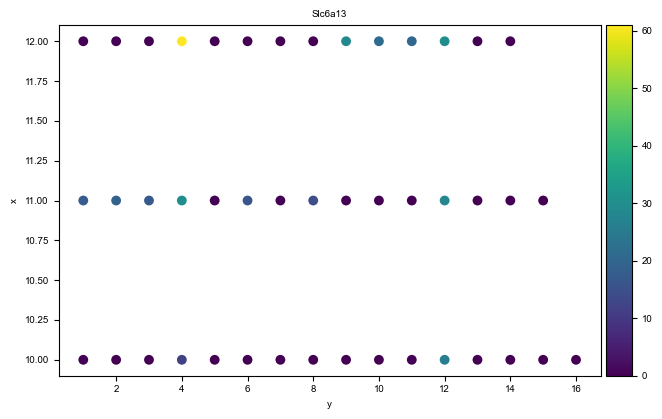

In [36]:
# 看基因的空间表达情况
import scanpy as sc
import numpy as np
import pandas as pd

adata = sc.read_h5ad("adata/roi_norm_ubc1e6.h5ad")
mask = (adata.obs["x"] >9) & (adata.obs["x"] <13 )    
adata = adata[mask].copy()

#adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 1), "sample"] = "spleem"
plt.figure()
sc.pl.scatter(adata, x="y", y="x", color="Slc6a13", size=200)  # 注意 x/y 轴方向按你的习惯调整

In [54]:

# 将csv转换为h5ad数据
import pandas as pd
import numpy as np
import anndata as ad
from scipy import sparse

csv_file = "adata/roi_norm_total1e6.csv"

df = pd.read_csv(csv_file)

# 基因列：除了 x,y 以外的所有列
gene_cols = [c for c in df.columns if c not in ("x", "y")]

# obs：ROI 信息
obs = df[["x", "y"]].copy()
obs["roi_id"] = [f"{int(x)}_{int(y)}" for x, y in zip(obs["x"], obs["y"])]
obs = obs.set_index("roi_id")

# X：表达矩阵（nROI x nGene）
X = df[gene_cols].to_numpy(dtype=np.float32)

# 可选：转稀疏（如果大多数是 0，会省很多空间）
X = sparse.csr_matrix(X)

# var：基因信息
var = pd.DataFrame(index=pd.Index(gene_cols, name="gene"))

adata = ad.AnnData(X=X, obs=obs, var=var)
adata.write_h5ad("adata/roi_norm_total1e6.h5ad")

print(adata)


AnnData object with n_obs × n_vars = 245 × 1535
    obs: 'x', 'y'


count    2.450000e+02
mean     3.688244e+06
std      2.891146e+06
min      1.483563e+06
25%      1.908793e+06
50%      2.387475e+06
75%      3.421142e+06
max      1.247708e+07
Name: total_cpm, dtype: float64


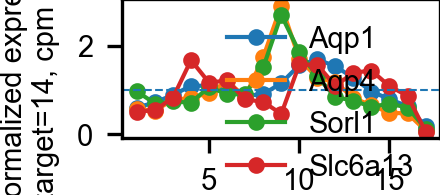

In [14]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
adata = sc.read_h5ad("adata/roi_norm_ubc1e6.h5ad")

# 如果你 X 是稀疏矩阵，sum 会返回矩阵，需要转一下
totals = np.asarray(adata.X.sum(axis=1)).ravel()
adata.obs["total_cpm"] = totals
adata.obs["n_genes_nonzero"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()

# 看看是否每个 ROI 总和≈1e6（允许少量数值误差；原本全0的 ROI 会是0）
print(adata.obs["total_cpm"].describe())
sc.pp.filter_cells(adata, min_genes=10)  # 你也可改成 50/100 视数据情况
# 或者按总量过滤
adata = adata[adata.obs["total_cpm"] > 0].copy()

#sc.pp.highly_variable_genes(adata, n_top_genes=1000, flavor="seurat_v3", subset=True)

adata.layers["cpm"] = adata.X.copy()   # 留一份原始 CPM

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#cortex_genes  = {"Lrp2","Aqp1","Slc6a13"}  ;        % 外/皮质
#medulla_genes = {"Aqp4","Avpr2","Car2","Spp1",'Btc'};      % 内/髓质（Spp1偏状态敏感
# ========= 你需要改的参数 =========
genes = ["Aqp1", "Aqp4", "Sorl1","Slc6a13"]   # 多个基因
x_target = 14
layer_name = "cpm"             # "log1p_cpm" / "cpm" / None(用adata.X)
agg = "mean"                         # "mean" 或 "median"
y_order = None                       # 例如 [1,2,3,4,5]；不填则按数值排序

# 画布与轴（可调）
fig_size_in = (1.47, 1.1)             # figure 尺寸（英寸）
ax_pos = (0.18, 0.18, 0.72, 0.42)    # [left,bottom,width,height] 0-1，轴位置与大小可调
save_pdf = "adata/kidney_show.pdf"                      # 例如 "x13_multiGene_normMean1.pdf"，不保存就 None

# ========= 字体：Arial 7pt =========
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ========= 1) 子集：x=13 =========
sub = adata[adata.obs["x"].astype(int) == x_target].copy()

# ========= 2) 提取多基因表达矩阵 =========
X = sub.layers[layer_name] if layer_name is not None else sub.X

genes_in = [g for g in genes if g in sub.var_names]
missing = [g for g in genes if g not in sub.var_names]
if missing:
    print("Warning: missing genes skipped:", missing)
if len(genes_in) == 0:
    raise ValueError("None of the requested genes are in adata.var_names")

idx = [sub.var_names.get_loc(g) for g in genes_in]
try:
    M = X[:, idx].toarray()          # 稀疏矩阵
except AttributeError:
    M = np.asarray(X[:, idx])        # dense

df = pd.DataFrame(M, columns=genes_in)
df["y"] = sub.obs["y"].values

# y 顺序控制
if y_order is None:
    y_order = sorted(pd.unique(df["y"]))

df["y"] = pd.Categorical(df["y"], categories=y_order, ordered=True)

# ========= 3) 按 y 聚合得到 profile: (y × genes) =========
if agg == "mean":
    prof = df.groupby("y", observed=True)[genes_in].mean()
elif agg == "median":
    prof = df.groupby("y", observed=True)[genes_in].median()
else:
    raise ValueError("agg must be 'mean' or 'median'")

prof = prof.reindex(y_order)  # 保证顺序

# ========= 4) 每个基因归一化：让该基因 across y 的平均=1 =========
prof_norm = prof.copy()
gene_means = prof_norm.mean(axis=0).replace(0, np.nan)   # 防止除0
prof_norm = prof_norm / gene_means

# ========= 5) 画图（ax 位置/大小可调） =========
fig = plt.figure(figsize=fig_size_in, dpi=300)
ax = fig.add_axes(ax_pos)

for g in genes_in:
    ax.plot(prof_norm.index.astype(float), prof_norm[g].values, marker="o", label=g,markersize=3,linewidth=1)

ax.set_xlabel("")
ax.set_ylabel(f"Normalized expression\n{x_target=}, {layer_name or 'X'} ({agg})")
#ax.set_title(f"x={x_target}", pad=2)

ax.legend(frameon=False, ncol=1)

# 可选：参考线 y=1
ax.axhline(1.0, linewidth=0.5, linestyle="--")

# 统一字体保险（避免某些环境不吃 rcParams）
for t in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
    t.set_fontname("Arial")
    t.set_fontsize(7)

if save_pdf:
    fig.savefig(save_pdf, dpi=300)   # 不用 bbox_inches='tight'，避免尺寸变化
plt.show()
plt.close(fig)



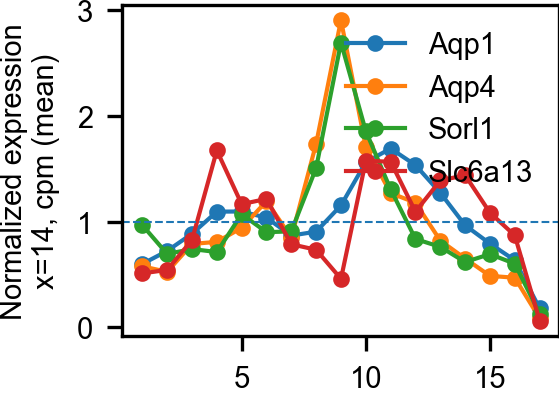

Figure size (mm): 59.00000000000001 × 41.99999999999999
Axes size (mm): 37.0 × 28.0


In [19]:
# ========= 5) 画图：固定“绘图区(Axes)物理尺寸” =========
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- 你要的绘图区尺寸（mm）----
AX_W_MM = 37   # 可改：绘图区宽度（mm）
AX_H_MM = 28   # 你要求：绘图区高度（mm）

# ---- 四周留白（mm）：用于放 y 轴标签、tick、legend 等 ----
LEFT_MM   = 18   # y 轴标签通常要更大；不够就加
RIGHT_MM  = 4
BOTTOM_MM = 10
TOP_MM    = 4

# ---- mm -> inch ----
mm2in = 1 / 25.4
AX_W_IN = AX_W_MM * mm2in
AX_H_IN = AX_H_MM * mm2in
LEFT_IN, RIGHT_IN, BOTTOM_IN, TOP_IN = [v * mm2in for v in (LEFT_MM, RIGHT_MM, BOTTOM_MM, TOP_MM)]

FIG_W_IN = LEFT_IN + AX_W_IN + RIGHT_IN
FIG_H_IN = BOTTOM_IN + AX_H_IN + TOP_IN

# ========= 字体：Arial 7pt + 禁止 tight 裁切（避免 AI 画板变小）=========
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": None,
    "savefig.pad_inches": 0,
})

# ========= 建图：Axes 尺寸严格固定 =========
fig = plt.figure(figsize=(FIG_W_IN, FIG_H_IN), dpi=300)
ax = fig.add_axes([
    LEFT_IN / FIG_W_IN,
    BOTTOM_IN / FIG_H_IN,
    AX_W_IN / FIG_W_IN,
    AX_H_IN / FIG_H_IN
])

for g in genes_in:
    ax.plot(
        prof_norm.index.astype(float),
        prof_norm[g].values,
        marker="o",
        markersize=3,
        linewidth=1,
        label=g
    )

ax.set_xlabel("")  # 需要 x 轴标题就写这里
ax.set_ylabel(f"Normalized expression\nx={x_target}, {layer_name or 'X'} ({agg})")

# legend 建议放在框内，避免被裁切
ax.legend(frameon=False, loc="upper right")

# 参考线 y=1
ax.axhline(1.0, linewidth=0.5, linestyle="--")

# 字体保险
for t in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
    t.set_fontname("Arial")
    t.set_fontsize(7)

# 保存：不要 bbox_inches="tight"，保证页面不被裁剪；Axes 尺寸也不会变
save_pdf = "adata/kidney_show_axesH28mm.pdf"
fig.savefig(save_pdf, dpi=300, bbox_inches=None, pad_inches=0)

plt.show()
plt.close(fig)

# 自检：打印 Axes 物理高度是否 28mm（应非常接近）
ax_box = ax.get_position()  # figure fraction
print("Figure size (mm):", FIG_W_IN*25.4, "×", FIG_H_IN*25.4)
print("Axes size (mm):",
      ax_box.width * FIG_W_IN * 25.4,
      "×",
      ax_box.height * FIG_H_IN * 25.4)


count    2.450000e+02
mean     1.000000e+06
std      5.974995e-02
min      9.999998e+05
25%      9.999999e+05
50%      1.000000e+06
75%      1.000000e+06
max      1.000000e+06
Name: total_cpm, dtype: float64


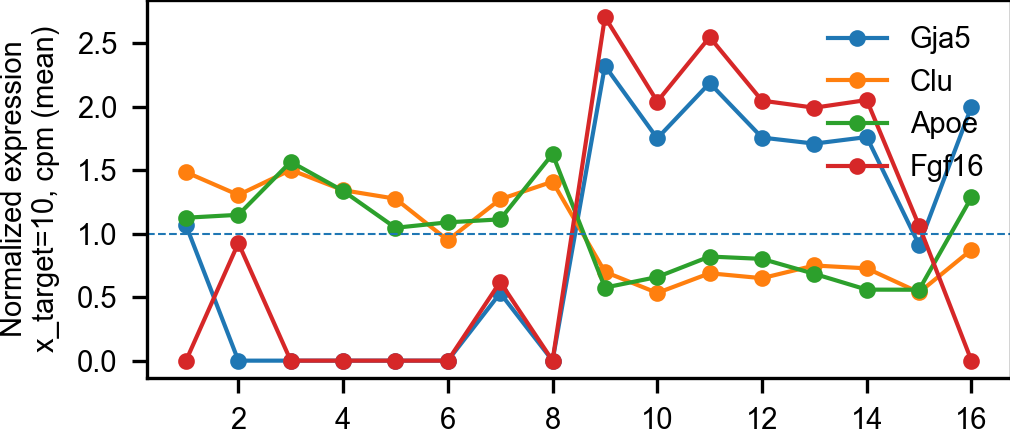

In [20]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
adata = sc.read_h5ad("adata/roi_norm_total1e6.h5ad")

# 如果你 X 是稀疏矩阵，sum 会返回矩阵，需要转一下
totals = np.asarray(adata.X.sum(axis=1)).ravel()
adata.obs["total_cpm"] = totals
adata.obs["n_genes_nonzero"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()

# 看看是否每个 ROI 总和≈1e6（允许少量数值误差；原本全0的 ROI 会是0）
print(adata.obs["total_cpm"].describe())
sc.pp.filter_cells(adata, min_genes=10)  # 你也可改成 50/100 视数据情况
# 或者按总量过滤
adata = adata[adata.obs["total_cpm"] > 0].copy()

#sc.pp.highly_variable_genes(adata, n_top_genes=1000, flavor="seurat_v3", subset=True)

adata.layers["cpm"] = adata.X.copy()   # 留一份原始 CPM

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#cortex_genes  = {"Lrp2","Aqp1","Slc6a13"}  ;        % 外/皮质
#medulla_genes = {"Aqp4","Avpr2","Car2","Spp1",'Btc'};      % 内/髓质（Spp1偏状态敏感
# ========= 你需要改的参数 =========
# genes = [ "Gja5", "Cd36","Clu","Cxcl12","Mdh1","Apoe","Gja1","Fgf16"]   # 多个基因
genes = [ "Gja5","Clu","Apoe","Fgf16"]
x_target = 10
layer_name = "cpm"             # "log1p_cpm" / "cpm" / None(用adata.X)
agg = "mean"                         # "mean" 或 "median"
y_order = None                       # 例如 [1,2,3,4,5]；不填则按数值排序

# 画布与轴（可调）
fig_size_in = (4.0, 3.0)             # figure 尺寸（英寸）
ax_pos = (0.18, 0.18, 0.72, 0.42)    # [left,bottom,width,height] 0-1，轴位置与大小可调
save_pdf = "adata/heart_show.pdf"                      # 例如 "x13_multiGene_normMean1.pdf"，不保存就 None

# ========= 字体：Arial 7pt =========
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ========= 1) 子集：x=13 =========
sub = adata[adata.obs["x"].astype(int) == x_target].copy()

# ========= 2) 提取多基因表达矩阵 =========
X = sub.layers[layer_name] if layer_name is not None else sub.X

genes_in = [g for g in genes if g in sub.var_names]
missing = [g for g in genes if g not in sub.var_names]
if missing:
    print("Warning: missing genes skipped:", missing)
if len(genes_in) == 0:
    raise ValueError("None of the requested genes are in adata.var_names")

idx = [sub.var_names.get_loc(g) for g in genes_in]
try:
    M = X[:, idx].toarray()          # 稀疏矩阵
except AttributeError:
    M = np.asarray(X[:, idx])        # dense

df = pd.DataFrame(M, columns=genes_in)
df["y"] = sub.obs["y"].values

# y 顺序控制
if y_order is None:
    y_order = sorted(pd.unique(df["y"]))

df["y"] = pd.Categorical(df["y"], categories=y_order, ordered=True)

# ========= 3) 按 y 聚合得到 profile: (y × genes) =========
if agg == "mean":
    prof = df.groupby("y", observed=True)[genes_in].mean()
elif agg == "median":
    prof = df.groupby("y", observed=True)[genes_in].median()
else:
    raise ValueError("agg must be 'mean' or 'median'")

prof = prof.reindex(y_order)  # 保证顺序

# ========= 4) 每个基因归一化：让该基因 across y 的平均=1 =========
prof_norm = prof.copy()
gene_means = prof_norm.mean(axis=0).replace(0, np.nan)   # 防止除0
prof_norm = prof_norm / gene_means

# ========= 5) 画图（ax 位置/大小可调） =========
fig = plt.figure(figsize=fig_size_in, dpi=300)
ax = fig.add_axes(ax_pos)

for g in genes_in:
    ax.plot(prof_norm.index.astype(float), prof_norm[g].values, marker="o", label=g,markersize=3,linewidth=1)

ax.set_xlabel("")
ax.set_ylabel(f"Normalized expression\n{x_target=}, {layer_name or 'X'} ({agg})")
#ax.set_title(f"x={x_target}", pad=2)

ax.legend(frameon=False, ncol=1)

# 可选：参考线 y=1
ax.axhline(1.0, linewidth=0.5, linestyle="--")

# 统一字体保险（避免某些环境不吃 rcParams）
for t in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
    t.set_fontname("Arial")
    t.set_fontsize(7)

if save_pdf:
    fig.savefig(save_pdf, dpi=300)   # 不用 bbox_inches='tight'，避免尺寸变化
plt.show()
plt.close(fig)



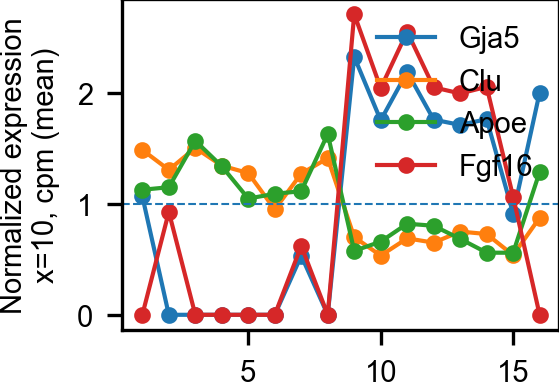

Figure size (mm): 59.00000000000001 × 41.99999999999999
Axes size (mm): 37.0 × 28.0


In [21]:
# ========= 5) 画图：固定“绘图区(Axes)物理尺寸” =========
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- 你要的绘图区尺寸（mm）----
AX_W_MM = 37   # 可改：绘图区宽度（mm）
AX_H_MM = 28   # 你要求：绘图区高度（mm）

# ---- 四周留白（mm）：用于放 y 轴标签、tick、legend 等 ----
LEFT_MM   = 18   # y 轴标签通常要更大；不够就加
RIGHT_MM  = 4
BOTTOM_MM = 10
TOP_MM    = 4

# ---- mm -> inch ----
mm2in = 1 / 25.4
AX_W_IN = AX_W_MM * mm2in
AX_H_IN = AX_H_MM * mm2in
LEFT_IN, RIGHT_IN, BOTTOM_IN, TOP_IN = [v * mm2in for v in (LEFT_MM, RIGHT_MM, BOTTOM_MM, TOP_MM)]

FIG_W_IN = LEFT_IN + AX_W_IN + RIGHT_IN
FIG_H_IN = BOTTOM_IN + AX_H_IN + TOP_IN

# ========= 字体：Arial 7pt + 禁止 tight 裁切（避免 AI 画板变小）=========
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": None,
    "savefig.pad_inches": 0,
})

# ========= 建图：Axes 尺寸严格固定 =========
fig = plt.figure(figsize=(FIG_W_IN, FIG_H_IN), dpi=300)
ax = fig.add_axes([
    LEFT_IN / FIG_W_IN,
    BOTTOM_IN / FIG_H_IN,
    AX_W_IN / FIG_W_IN,
    AX_H_IN / FIG_H_IN
])

for g in genes_in:
    ax.plot(
        prof_norm.index.astype(float),
        prof_norm[g].values,
        marker="o",
        markersize=3,
        linewidth=1,
        label=g
    )

ax.set_xlabel("")  # 需要 x 轴标题就写这里
ax.set_ylabel(f"Normalized expression\nx={x_target}, {layer_name or 'X'} ({agg})")

# legend 建议放在框内，避免被裁切
ax.legend(frameon=False, loc="upper right")

# 参考线 y=1
ax.axhline(1.0, linewidth=0.5, linestyle="--")

# 字体保险
for t in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
    t.set_fontname("Arial")
    t.set_fontsize(7)

# 保存：不要 bbox_inches="tight"，保证页面不被裁剪；Axes 尺寸也不会变
save_pdf = "adata/heart_show_axesH28mm.pdf"
fig.savefig(save_pdf, dpi=300, bbox_inches=None, pad_inches=0)

plt.show()
plt.close(fig)

# 自检：打印 Axes 物理高度是否 28mm（应非常接近）
ax_box = ax.get_position()  # figure fraction
print("Figure size (mm):", FIG_W_IN*25.4, "×", FIG_H_IN*25.4)
print("Axes size (mm):",
      ax_box.width * FIG_W_IN * 25.4,
      "×",
      ax_box.height * FIG_H_IN * 25.4)
